In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [4]:
train_set.data.shape, train_set.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [5]:
train_set, test_set = torch.utils.data.random_split(train_set, [50000, 10000])
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

In [6]:
# MINST Model
class MNISTModel(torch.nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(28*28, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )


    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [7]:
model = MNISTModel()
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
model = MNISTModel()
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 1
all_losses = []
every_n_batches = 100
for epoch in range(epochs):
    for batch, (X, y) in enumerate(train_loader):
        print(f"Epoch {epoch+1}, Batch {batch+1} of {len(train_loader)}", end="\r")
        pred = model(X)
        loss = loss_fn(pred, y)
        all_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (batch+1) % every_n_batches == 0:
            print(f"Epoch {epoch+1}, Batch {batch+1}, average loss: {np.mean(all_losses[-every_n_batches:]):.4f}")
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Batch 100, average loss: 0.6458
Epoch 1, Batch 200, average loss: 0.2850
Epoch 1, Batch 300, average loss: 0.2214
Epoch 1, Batch 400, average loss: 0.1741
Epoch 1, Batch 500, average loss: 0.1652
Epoch 1, Batch 600, average loss: 0.1440
Epoch 1, Batch 700, average loss: 0.1378
Epoch 1, Loss: 0.2613 782


In [15]:
test_image, test_label = test_set.dataset[0]

In [16]:
test_image.shape, test_label

(torch.Size([1, 28, 28]), 5)

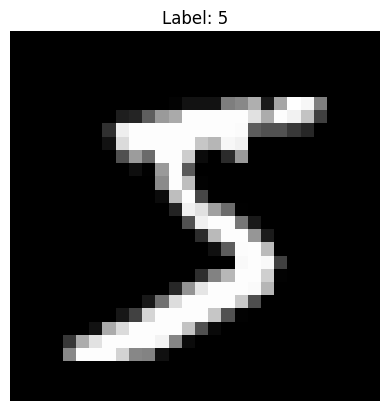

In [17]:
# show the image
plt.imshow(test_image.squeeze(), cmap="gray")
plt.title(f"Label: {test_label}")
plt.axis("off")
plt.show()

In [19]:
test_image.shape

torch.Size([1, 1, 28, 28])

In [18]:
model.eval()
with torch.inference_mode():
    test_image = test_image.unsqueeze(0)  # Add batch dimension
    pred = model(test_image)
    predicted_label = pred.argmax(dim=1).item()
print(f"Predicted label: {predicted_label}, True label: {test_label}")

Predicted label: 5, True label: 5


In [21]:
pred, pred.argmax(dim=1)

(tensor([[ -4.6246,  -3.4166,  -4.2204,   7.3804, -15.6483,  12.0115,  -6.7165,
           -4.5812,  -4.3370,  -1.5900]]),
 tensor([5]))

In [ ]:
# evaluate the model on the test set
corret_predictions = 0 # count the number of correct predictions
total_predictions = 0 # count the total number of predictions
for data in test_set:
    # loop through the test set and make predictions
    print(f"Evaluating on test image {total_predictions+1} of {len(test_set)}", end="\r")
    total_predictions += 1
    test_image, test_label = data
    pred = model(test_image.unsqueeze(0))    # add batch dimension
    predicted_label = pred.argmax(dim=1).item()
    if predicted_label == test_label:
        corret_predictions += 1
    if total_predictions % 1000 == 0:
        print(f"Evaluated {total_predictions} images, current accuracy: {corret_predictions/total_predictions:.4f}")
accuracy = corret_predictions / total_predictions
print(f"Test set accuracy: {accuracy:.4f}")


Evaluated 1000 images, current accuracy: 0.9660
Evaluated 2000 images, current accuracy: 0.9670
Evaluated 3000 images, current accuracy: 0.9677
Evaluated 4000 images, current accuracy: 0.9680
Evaluated 5000 images, current accuracy: 0.9692
Evaluated 6000 images, current accuracy: 0.9688
Evaluated 7000 images, current accuracy: 0.9699
Evaluated 8000 images, current accuracy: 0.9684
Evaluated 9000 images, current accuracy: 0.9678
Evaluated 10000 images, current accuracy: 0.9678
Test set accuracy: 0.9678


In [13]:
true_false_compare =  pred.argmax(dim=1)  == y

In [15]:
# give me the true position
y[true_false_compare] 

tensor([2, 2, 4])

tensor(False)